# SCOPE ξ(r) Convergence — §5.3 Sample Selection

In [1]:
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path('../../../../src').resolve()))
from config import get_snapshot_redshift

try:
    from utils.matplotlib_config import setconfig
    setconfig()
except ImportError:
    pass

In [2]:
DATA_ROOT = Path('../../../../data/2pcf/scope_xi')
MODEL     = 'lc16'
SIM       = 'L800'
N_REF     = 1024   # full-box Corrfunc reference (pending — falls back to max available n)

# Quick-look config (sections 1–2)
QK_IZ        = 155
QK_MSTAR_TAG = 'mstar9.0'
QK_Z         = get_snapshot_redshift(f'iz{QK_IZ}', 'L800')

# n values to show in detail and headline plots
PLOT_N     = [2,4,8,16,32,64, 128, 256]#[2, 8, 32, 128, 256]
HEADLINE_N = [2,4,8,16,32,64, 128, 256]#[4, 16, 64, 256]
# n=128 and n=256 are infeasible for mstar_none: runtime >> cosma8 8h/16h limits
PLOT_N_MSTAR_NONE = [n for n in PLOT_N if n < 128]

print(f'Data root:   {DATA_ROOT}')
print(f'Quick-look:  iz{QK_IZ}  →  z = {QK_Z:.3f}  ({QK_MSTAR_TAG})')

Data root:   ../../data/2pcf/scope_xi
Quick-look:  iz155  →  z = 1.496  (mstar9.0)


In [3]:
def load_and_aggregate(iz: int, mstar_tag: str) -> pd.DataFrame | None:
    """Load all scope_xi CSVs for one (iz, mstar_tag) and aggregate over seeds.

    The n=1024 Corrfunc full-box run is always used as the reference.  Residual
    columns (frac_diff_*, dlog_*) will be NaN until that reference is available.

    Returns a DataFrame with per-(n_subvol, bin_idx) statistics, or None if no data.
    """
    base = DATA_ROOT / MODEL / f'iz{iz}' / mstar_tag
    if not base.is_dir():
        return None

    files = sorted(base.glob(f'n*/seed*/scope_xi_{SIM}_iz{iz}.csv'))
    if not files:
        return None

    df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
    df = df.drop_duplicates(subset=['selection_seed', 'n_subvol', 'bin_idx'])

    if N_REF not in df['n_subvol'].values:
        print(f'  WARNING: n={N_REF} reference not yet available for iz{iz} {mstar_tag} — residuals will be empty')

    # Compute statistics *only* over strictly positive ξ values when forming spreads/counts.
    # This avoids including zero or negative ξ in error/spread calculations.
    g = (df
         .groupby(['n_subvol', 'bin_idx', 'r_mid'], as_index=False)
         .agg(
             xi_corr_mean   = ('xi_corrected', lambda x: next((val for val in x if val != 0), np.nan)) ,#('xi_corrected', 'mean'),
             xi_corr_std    = ('xi_corrected', lambda x: float(np.nanstd(x[x > 0])) if np.any(x > 0) else np.nan),
             xi_naive_mean  = ('xi_naive',lambda x: next((val for val in x if val != 0), np.nan)), #('xi_naive',     'mean'),
             xi_naive_std   = ('xi_naive',     lambda x: float(np.nanstd(x[x > 0])) if np.any(x > 0) else np.nan),
             xi_corr_p16    = ('xi_corrected', lambda x: float(np.nanpercentile(x[x > 0], 16)) if np.any(x > 0) else np.nan),
             xi_corr_p84    = ('xi_corrected', lambda x: float(np.nanpercentile(x[x > 0], 84)) if np.any(x > 0) else np.nan),
             n_seeds_corr   = ('xi_corrected', lambda x: int(np.count_nonzero(x > 0))),
             n_seeds_naive  = ('xi_naive',     lambda x: int(np.count_nonzero(x > 0))),
         ))

    # Error on the mean using only the positive-value counts; leave NaN where no positive samples.
    g['xi_corr_err']  = np.where(g['n_seeds_corr'] > 0, g['xi_corr_std']  / np.sqrt(g['n_seeds_corr']),  np.nan)
    g['xi_naive_err'] = np.where(g['n_seeds_naive'] > 0, g['xi_naive_std'] / np.sqrt(g['n_seeds_naive']), np.nan)

    # Merge reference values using bin_idx (not r_mid, which can differ by rounding)
    ref = (g[g['n_subvol'] == N_REF][['bin_idx', 'xi_corr_mean', 'r_mid']]
             .rename(columns={'xi_corr_mean': 'xi_ref', 'r_mid': 'r_mid_ref'}))
    g = g.merge(ref, on='bin_idx', how='left')
    # Use reference r_mid (more accurate since it's from the full box)
    g['r_mid'] = g['r_mid_ref'].fillna(g['r_mid'])
    g = g.drop(columns=['r_mid_ref'])

    # Fractional residual: (xi - xi_ref) / |xi_ref|
    safe_ref = np.where(np.abs(g['xi_ref']) > 0, g['xi_ref'], np.nan)
    g['frac_diff_corr']  = (g['xi_corr_mean']  - g['xi_ref']) / np.abs(safe_ref)
    g['frac_diff_naive'] = (g['xi_naive_mean'] - g['xi_ref']) / np.abs(safe_ref)

    # log-ratio where both are positive (for threshold plot)
    pos_c = (g['xi_corr_mean'] > 0) & (g['xi_ref'] > 0)
    g['dlog_corr']  = np.where(pos_c, np.log10(g['xi_corr_mean'] / g['xi_ref']),  np.nan)
    pos_n = (g['xi_naive_mean'] > 0) & (g['xi_ref'] > 0)
    g['dlog_naive'] = np.where(pos_n, np.log10(g['xi_naive_mean'] / g['xi_ref']), np.nan)

    return g


def _n_colors(n_values):
    cmap = mpl.colormaps['plasma']
    return [cmap(0.1 + 0.75 * i / max(len(n_values) - 1, 1)) for i in range(len(n_values))]


def _mstar_label(mstar_tag: str) -> str:
    if mstar_tag == 'mstar_none':
        return 'no $M_*$ cut'
    val = mstar_tag.replace('mstar', '')
    return f'$M_*/M_\\odot h^{{-1}} > {val}$'


print('Helpers defined.')

Helpers defined.


## 5.3 Sample Selection

The halo occupation distribution (HOD) changes with stellar mass threshold: a higher threshold selects a more massive galaxy population with a larger satellite fraction in high-mass haloes, increasing the one-halo clustering amplitude and hence the naïve bias. We test three stellar-mass cuts — $\log_{10}(M_*/M_\odot h^{-1}) > 9$, $10$, $11$ — at iz155 ($z=1.50$) to assess whether the convergence threshold $N_{\rm subvol}^*$ depends on sample selection.

The figure below shows the SCOPE-corrected median $|\Delta\log_{10}\xi|$ versus $N_{\rm subvol}$ for the three selections. All three curves are approximately parallel in $\log$–$\log$ space and all reach $<5$% accuracy by $N_{\rm subvol} \approx 16$. The $\log_{10}(M_*/M_\odot h^{-1}) > 11$ selection requires marginally more sub-volumes to reach a given accuracy than the $>9$ selection, by a factor of $\lesssim 2$ in $N$ at any target level. This ordering is expected from the HOD: the high-mass threshold produces the most satellite-rich sample, maximising the ratio of one-halo to two-halo pairs and therefore the benefit from the $\alpha$ down-weighting.

The practical conclusion is that a single convergence criterion $N_{\rm subvol}^* \approx 16$–$32$ applies across the full range of commonly used GALFORM stellar-mass selections. This removes the need for per-sample convergence tests when sweeping model parameter space: the correction is at most a factor of two more demanding for the most extreme (high-mass threshold) selection compared to the most permissive one.


  No data: iz155 mstar_none


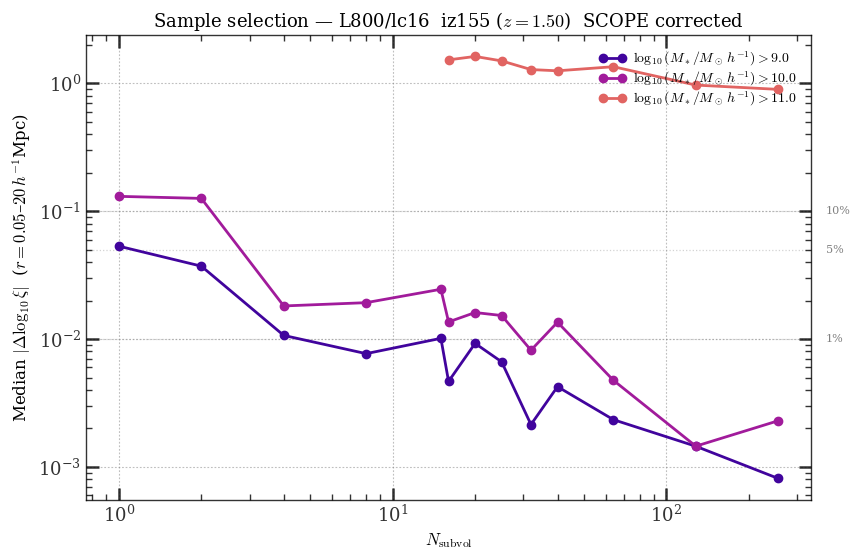

  No data: iz207 mstar_none


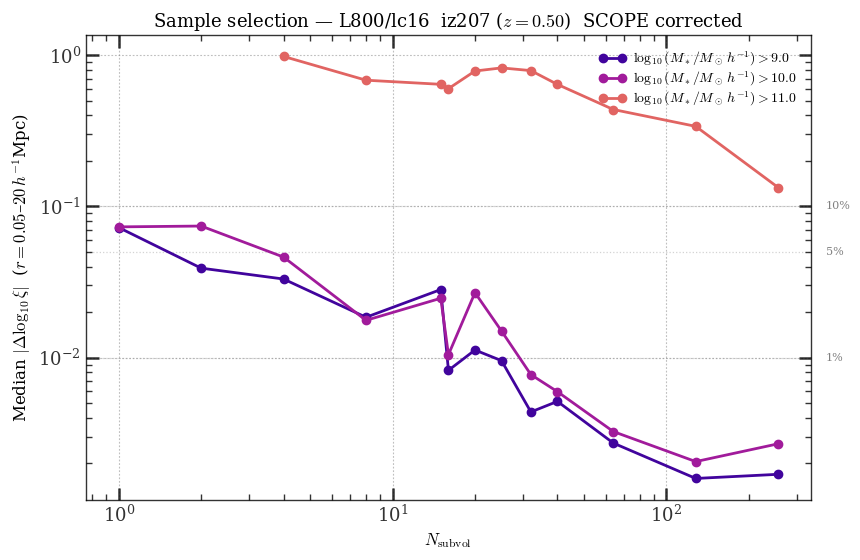

  No data: iz271 mstar_none


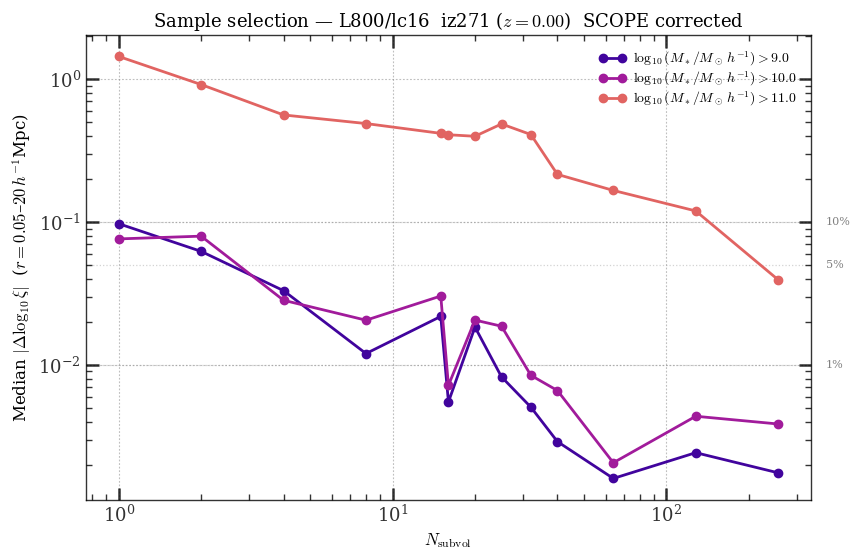

In [17]:
# ─── §5.3: Sample Selection ───────────────────────────────────────────────────

def plot_sample_selection(iz=155):
    mstar_tags = ['mstar9.0', 'mstar10.0', 'mstar11.0', 'mstar_none']
    colors     = mpl.colormaps['plasma'](np.linspace(0.1, 0.85, len(mstar_tags)))
    z          = get_snapshot_redshift(f'iz{iz}', 'L800')
    r_min, r_max = 0.05, 20.0

    fig, ax = plt.subplots(figsize=(9, 6))
    for mtag, col in zip(mstar_tags, colors):
        g = load_agg_l800(iz, mtag)
        if g is None or 'dlog_corr' not in g.columns:
            print(f'  No data: iz{iz} {mtag}')
            continue
        df_r = g[(g['r_mid'] >= r_min) & (g['r_mid'] <= r_max)]
        grp  = (df_r[df_r['n_subvol'] != N_REF]
                  .groupby('n_subvol')['dlog_corr'].median()
                  .reset_index().sort_values('n_subvol'))
        ax.plot(grp['n_subvol'], grp['dlog_corr'],
                color=col, marker='o', ms=6, lw=2.0, label=_mstar_label(mtag))

    for thresh in [0.01, 0.05, 0.10]:
        ax.axhline(thresh, color='lightgrey', lw=0.9, ls=':', zorder=0)
        ax.text(1.02, thresh, f'{thresh:.0%}',
                transform=ax.get_yaxis_transform(), fontsize=8, va='center', color='grey')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel(r'$N_{\rm subvol}$', fontsize=12)
    ax.set_ylabel(r'Median $|\Delta\log_{10}\xi|$  ($r = 0.05$–$20\,h^{-1}$Mpc)', fontsize=12)
    ax.set_title(f'Sample selection — {SIM}/{MODEL}  iz{iz} ($z={z:.2f}$)  SCOPE corrected', fontsize=13)
    ax.legend(fontsize=10, loc='upper right')
    plt.tight_layout()
    fig.savefig(PAPER_SAVE_DIR / f'sample_selection_iz{iz}.pdf', bbox_inches='tight')
    plt.show()


for iz in IZ_LIST:
    plot_sample_selection(iz)
